## 1. Data Ingestion and Hillas Parameter Mapping

The dataset is provided in a raw format (`.data`). It contains multivariate measurements characterizing the geometric properties (Hillas parameters) of electromagnetic showers induced by cosmic rays and detected by an atmospheric Cherenkov telescope. 

We will load the data array and assign the corresponding physical variable names manually, as the raw file lacks a header row. The target variable is dichotomous: `g` (gamma-ray signal) and `h` (hadronic background noise).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Definir los nombres de las variables basados en la documentación física (.names)
hillas_parameters = [
    'fLength',   # Eje mayor de la elipse [mm]
    'fWidth',    # Eje menor de la elipse [mm]
    'fSize',     # Logaritmo de la suma del contenido de los píxeles
    'fConc',     # Fracción de luz en los dos píxeles más brillantes
    'fConc1',    # Fracción de luz en el píxel más brillante
    'fAsym',     # Asimetría de la distribución de luz
    'fM3Long',   # Tercer momento longitudinal
    'fM3Trans',  # Tercer momento transversal
    'fAlpha',    # Ángulo del eje mayor respecto al origen [grados]
    'fDist',     # Distancia del centro de la elipse al origen [mm]
    'class'      # Variable objetivo: 'g' (gamma) o 'h' (hadron)
]

# Cargar la matriz de eventos, indicando explícitamente que no hay encabezado
df = pd.read_csv('../data/magic04.data', header=None, names=hillas_parameters)

# Validar la estructura del DataFrame
print(f"Dimensiones de la matriz de eventos: {df.shape[0]} eventos y {df.shape[1]} parámetros.")
display(df.head())

Dimensiones de la matriz de eventos: 19020 eventos y 11 parámetros.


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


## 2. Target Binarization and Class Distribution

For machine learning applications, the categorical target variable must be numerically encoded. We define our positive class (1) as the gamma-ray signal (`g`) and the negative class (0) as the hadronic background noise (`h`).

Subsequently, we analyze the class balance. In real observational astrophysics, hadronic events vastly outnumber gamma-ray photons. Understanding this baseline distribution is critical for selecting appropriate evaluation metrics (like the F1-Score or ROC-AUC) instead of simple accuracy.

Distribución de eventos:
Gamma (Señal - 1): 12332 eventos
Hadrón (Fondo - 0): 6688 eventos
Proporción Señal/Fondo: 1.84



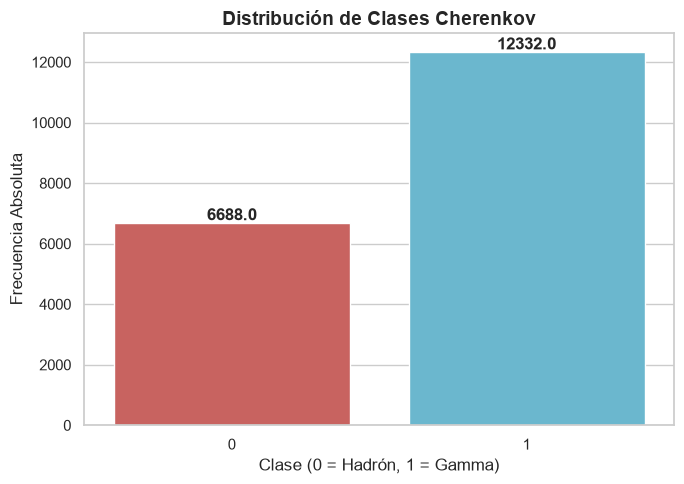

In [4]:
# 1. Binarización de la variable objetivo
df['class'] = df['class'].map({'g': 1, 'h': 0})

# 2. Verificar la distribución exacta
class_counts = df['class'].value_counts()
print("Distribución de eventos:")
print(f"Gamma (Señal - 1): {class_counts[1]} eventos")
print(f"Hadrón (Fondo - 0): {class_counts[0]} eventos")
print(f"Proporción Señal/Fondo: {class_counts[1]/class_counts[0]:.2f}\n")

# 3. Visualización del balance
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='class', hue='class', palette=['#d9534f', '#5bc0de'], legend=False)
plt.title('Distribución de Clases Cherenkov', fontsize=14, fontweight='bold')
plt.xlabel('Clase (0 = Hadrón, 1 = Gamma)', fontsize=12)
plt.ylabel('Frecuencia Absoluta', fontsize=12)

# Añadir las etiquetas de datos sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Physical Parameter Distributions (Kernel Density Estimation)

To understand the complexity of the classification task, we visualize the continuous distributions of two critical Hillas parameters:
- **`fAlpha`**: The angle between the major axis of the ellipse and the vector to the origin. Gamma rays typically point towards the camera center (lower alpha).
- **`fLength`**: The major axis of the ellipse, indicating the longitudinal development of the cascade.

Significant overlap in these distributions indicates a highly non-linear classification boundary, necessitating advanced algorithms.

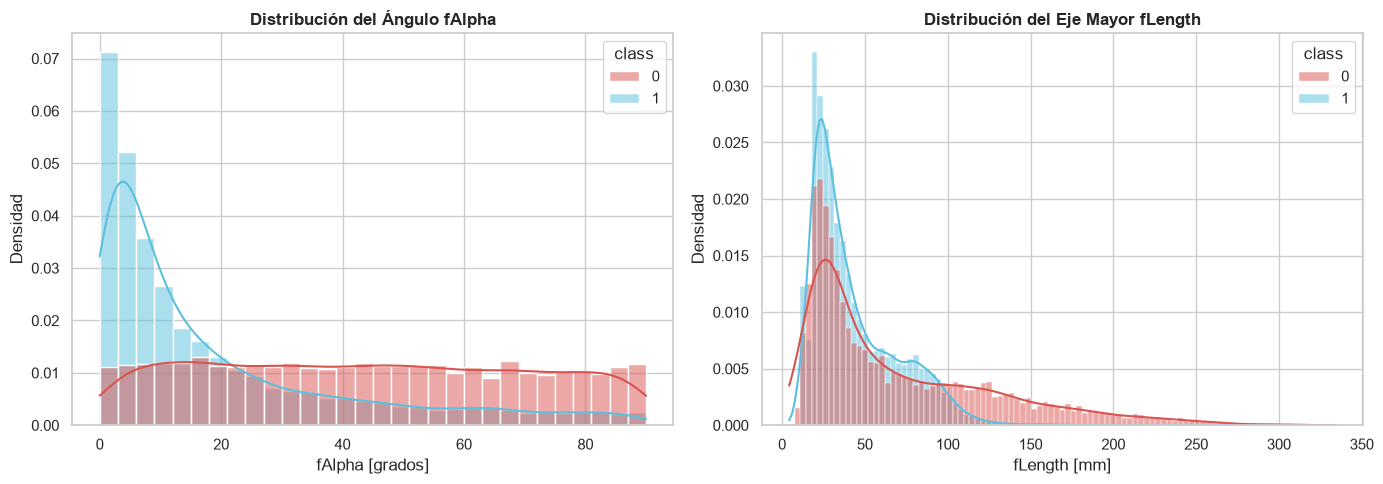

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de fAlpha
sns.histplot(data=df, x='fAlpha', hue='class', kde=True, stat="density", common_norm=False, 
             palette=['#d9534f', '#5bc0de'], ax=axes[0])
axes[0].set_title('Distribución del Ángulo fAlpha', fontweight='bold')
axes[0].set_xlabel('fAlpha [grados]')
axes[0].set_ylabel('Densidad')

# Distribución de fLength
sns.histplot(data=df, x='fLength', hue='class', kde=True, stat="density", common_norm=False, 
             palette=['#d9534f', '#5bc0de'], ax=axes[1])
axes[1].set_title('Distribución del Eje Mayor fLength', fontweight='bold')
axes[1].set_xlabel('fLength [mm]')
axes[1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing and Tensor Scaling

Artificial neural networks are highly sensitive to unscaled feature matrices, particularly when physical parameters span different orders of magnitude and units (e.g., coordinates in millimeters vs. angles in degrees). 

In this section, we perform:
1. **Feature-Target Segregation:** Isolating the 10 Hillas parameters ($X$) from the dichotomous target variable ($y$).
2. **Data Partitioning:** Allocating 80% of the events for gradient optimization and reserving 20% as an unseen test set for final evaluation.
3. **Standardization:** Applying a `StandardScaler` to transform the feature space such that each variable exhibits a mean of $\mu = 0$ and a standard deviation of $\sigma = 1$. The scaler is fitted exclusively on the training set to prevent data leakage.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separar características (X) y variable objetivo (y)
X = df.drop('class', axis=1)
y = df['class']

# 2. Partición del conjunto de datos (80% Entrenamiento, 20% Prueba)
# Se utiliza stratify=y para mantener la proporción matemática de las clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Dimensiones del conjunto de entrenamiento: {X_train.shape}")
print(f"Dimensiones del conjunto de prueba: {X_test.shape}\n")

# 3. Inicialización y ajuste del StandardScaler
scaler = StandardScaler()

# Ajustar el escalador SOLO con los datos de entrenamiento y transformar
X_train_scaled = scaler.fit_transform(X_train)

# Transformar los datos de prueba usando los parámetros (media/varianza) del conjunto de entrenamiento
X_test_scaled = scaler.transform(X_test)

# 4. Verificación de la transformación matemática
print("Media de las características estandarizadas (debe ser aprox 0):")
print(np.mean(X_train_scaled, axis=0).round(3))
print("\nDesviación estándar de las características estandarizadas (debe ser 1):")
print(np.std(X_train_scaled, axis=0).round(3))

Dimensiones del conjunto de entrenamiento: (15216, 10)
Dimensiones del conjunto de prueba: (3804, 10)

Media de las características estandarizadas (debe ser aprox 0):
[ 0. -0.  0. -0. -0.  0. -0. -0.  0. -0.]

Desviación estándar de las características estandarizadas (debe ser 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Deep Learning Architecture (Multi-Layer Perceptron)

To resolve the highly non-linear classification boundary between gamma-ray signals and hadronic noise, we construct a deep Multi-Layer Perceptron (MLP).

**Architecture Configuration:**
- **Input Layer:** Dynamically sized to the 10 Hillas parameters.
- **Hidden Layers:** Two dense layers (64 and 32 neurons) utilizing `ReLU` activations to capture complex physical interactions.
- **Regularization:** Strategic `Dropout` layers are injected to randomly deactivate neurons during training. This forces the network to learn robust, distributed representations of the physical events rather than memorizing noise patterns.
- **Output Layer:** A single neuron with a `Sigmoid` activation function, outputting a continuous probability bounded between [0, 1] for binary classification.
- **Loss Function:** Binary Crossentropy, optimal for dichotomous probability estimation.

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# 1. Capturar dinámicamente la dimensión de los tensores de entrada (10 parámetros)
input_dim = X_train_scaled.shape[1]

# 2. Construcción de la topología Secuencial
model = Sequential([
    Input(shape=(input_dim,)), # Capa de entrada explícita (Keras 3 Standard)
    
    # Capa de extracción de características primarias
    Dense(64, activation='relu'),
    Dropout(0.3), # Apagar el 30% de las neuronas aleatoriamente
    
    # Capa de refinamiento
    Dense(32, activation='relu'),
    Dropout(0.2), # Apagar el 20% de las neuronas aleatoriamente
    
    # Capa de salida binaria (Probabilidad de ser un Rayo Gamma)
    Dense(1, activation='sigmoid')
])

# 3. Compilación del grafo computacional
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Desplegar el resumen estructural
print("Arquitectura de la Red Neuronal Inicializada:")
model.summary()

Arquitectura de la Red Neuronal Inicializada:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Model Training and Optimization

We initiate the training phase using the Adam optimizer. The dataset is trained over 50 epochs with a batch size of 128 to ensure stable gradient updates. 

A critical component of this step is the `validation_split=0.2`, which isolates 20% of the training data. The model evaluates its loss and accuracy on this unseen validation subset at the end of every epoch, allowing us to monitor the generalization capacity in real-time and verify the efficacy of our Dropout regularization.

In [9]:
import os

# Crear directorios para los artefactos del proyecto
os.makedirs('models', exist_ok=True)
os.makedirs('assets', exist_ok=True)

# Hiperparámetros
EPOCHS = 50
BATCH_SIZE = 128

print(" Iniciando la optimización de la red neuronal...\n")

# Ejecutar el entrenamiento
history = model.fit(
    X_train_scaled, 
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2, # 20% para validación interna
    verbose=1
)

# Guardar el modelo entrenado
model_path = 'models/magic_gamma_classifier.keras'
model.save(model_path)
print(f"\n Modelo guardado en: {model_path}")


 Iniciando la optimización de la red neuronal...

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8526 - loss: 0.3604 - val_accuracy: 0.8436 - val_loss: 0.3616
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8478 - loss: 0.3602 - val_accuracy: 0.8541 - val_loss: 0.3558
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8541 - loss: 0.3524 - val_accuracy: 0.8548 - val_loss: 0.3547
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8538 - loss: 0.3491 - val_accuracy: 0.8551 - val_loss: 0.3494
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8576 - loss: 0.3485 - val_accuracy: 0.8535 - val_loss: 0.3482
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8568 - loss: 0.3417 - val_accuracy: 0.8545 - val_loss: 0.3465
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8612 - loss: 0.3368 - val_accuracy: 0.8551 - val_loss: 0.3428
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8622

## 7. Learning Curves and Model Convergence

To validate the stability of our neural network, we plot the loss and accuracy metrics over the 50 epochs. 
A healthy convergence is indicated by the tight tracking of the validation curves alongside the training curves, confirming that our regularization strategy effectively prevented overfitting.

 Gráfica guardada como 'learning_curves.png' en la carpeta assets.


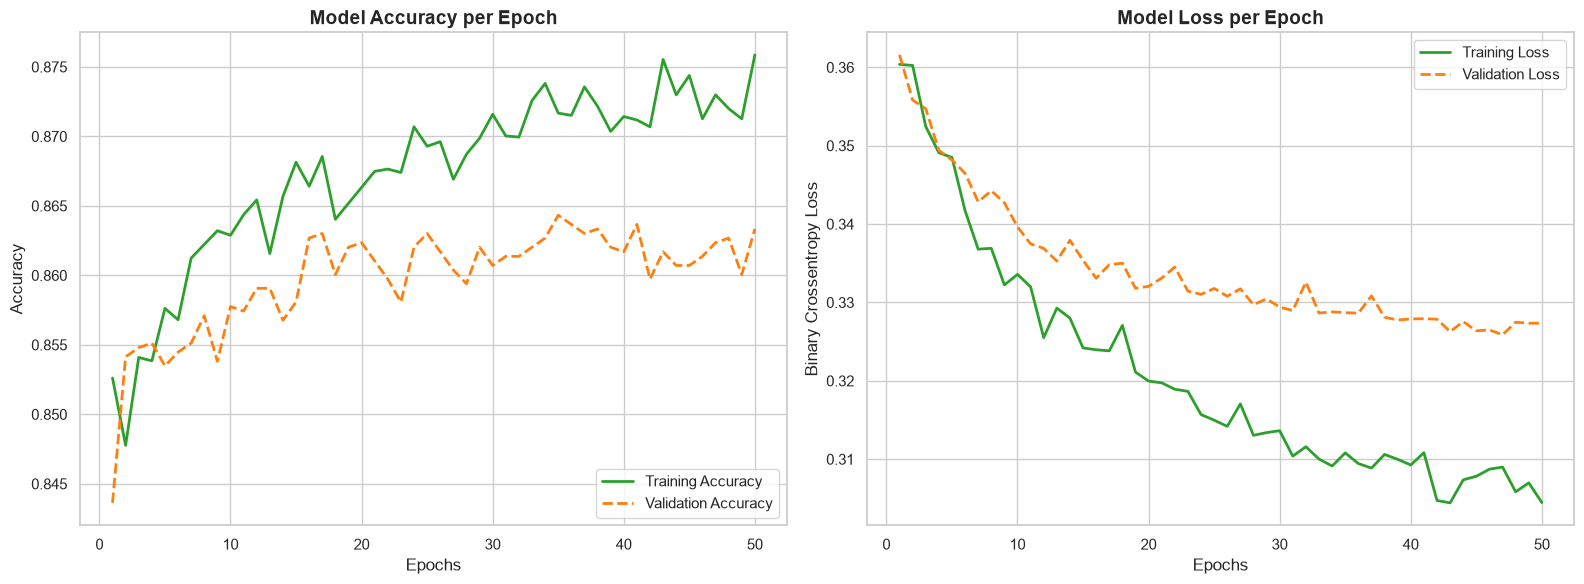

In [11]:
# Extraer métricas del historial
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, EPOCHS + 1)

# Crear la figura
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Curva de Precisión (Accuracy)
axes[0].plot(epochs_range, acc, label='Training Accuracy', color='#2ca02c', linewidth=2)
axes[0].plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy per Epoch', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')

# 2. Curva de Pérdida (Loss)
axes[1].plot(epochs_range, loss, label='Training Loss', color='#2ca02c', linewidth=2)
axes[1].plot(epochs_range, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='--')
axes[1].set_title('Model Loss per Epoch', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Binary Crossentropy Loss', fontsize=12)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('assets/learning_curves.png', dpi=300)
print(" Gráfica guardada como 'learning_curves.png' en la carpeta assets.")
plt.show()

## 8. Final Evaluation on Unseen Test Data

The ultimate test for our model is its performance on the 20% hold-out test set. We evaluate this using:
1. **Confusion Matrix:** To visualize True Positives (Gamma correctly identified) vs False Positives (Hadrons misclassified as Gamma).
2. **Classification Report:** To compute Precision, Recall, and the F1-Score.
3. **ROC Curve & AUC:** The industry standard for binary classifiers, illustrating the trade-off between the true positive rate and false positive rate across different probability thresholds.

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification Report (Test Set):

              precision    recall  f1-score   support

  Hadron (0)       0.90      0.72      0.80      1338
   Gamma (1)       0.86      0.96      0.91      2466

    accuracy                           0.87      3804
   macro avg       0.88      0.84      0.86      3804
weighted avg       0.88      0.87      0.87      3804


 Matriz y Curva ROC guardadas como 'evaluation_metrics.png' en la carpeta assets.


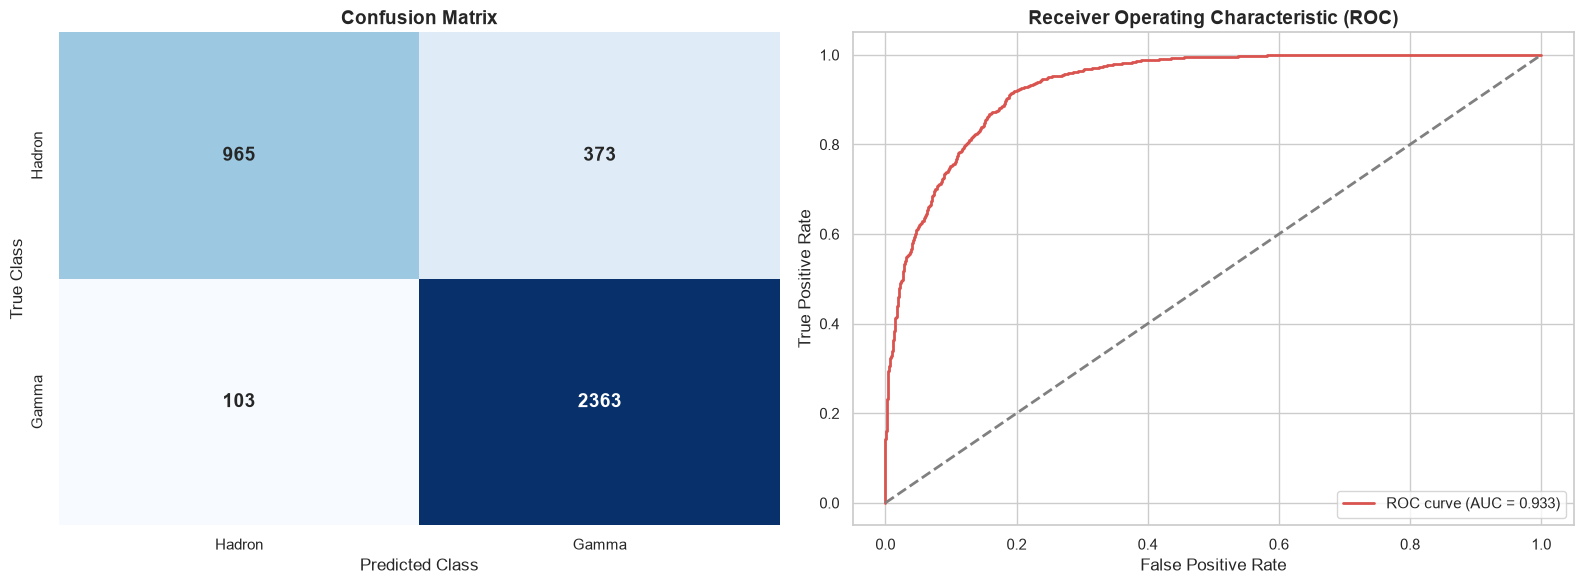

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Predicciones probabilísticas y binarias
y_pred_prob = model.predict(X_test_scaled).ravel() # Probabilidades continuas
y_pred = (y_pred_prob > 0.5).astype(int)           # Clasificación con umbral de 0.5

# 2. Reporte de Clasificación
print("Classification Report (Test Set):\n")
print(classification_report(y_test, y_pred, target_names=['Hadron (0)', 'Gamma (1)']))

# 3. Preparar la figura para la Matriz y la Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Hadron', 'Gamma'], yticklabels=['Hadron', 'Gamma'],
            cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Class', fontsize=12)
axes[0].set_ylabel('True Class', fontsize=12)

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#d9534f', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig('assets/evaluation_metrics.png', dpi=300)
print("\n Matriz y Curva ROC guardadas como 'evaluation_metrics.png' en la carpeta assets.")
plt.show()